## Introduction

In this workflow, we demonstrate how to integrate **COMPASS** with a **Cox Proportional Hazards (CoxPH) model** for survival prediction. COMPASS acts as a feature extractor by transforming transcriptomic profiles into **44 pretrained high-level tumor immune microenvironment (TIME) concepts**, which provide biologically meaningful and interpretable representations of the patient samples. These concept-level features are then used as covariates in a CoxPH model, enabling robust estimation of risk scores and survival outcomes. By coupling COMPASS with classical survival analysis, we combine the strengths of deep representation learning (capturing complex biological signals) with statistical modeling (transparent hazard estimation and interpretability). This integration provides a practical framework for **predicting survival, stratifying patients into risk groups, and evaluating clinical utility of TIME-derived features** in immuno-oncology studies.


In [1]:
from compass.utils import plot_embed_with_label
from compass import PreTrainer, FineTuner, loadcompass #, get_minmal_epoch
from compass.utils import plot_embed_with_label, plot_performance, score2
from compass.tokenizer import CANCER_CODE
import os
from tqdm import tqdm
from itertools import chain
import pandas as pd
import numpy as np
import random, torch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style = 'white', font_scale=1.3)
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from lifelines.utils import concordance_index 
from samecode.survival.plot import KMPlot
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

## 01. Load the data and COMPASS model

In [3]:
## load model
model = loadcompass('https://www.immuno-compass.com/download/model/pretrainer.pt', map_location='cpu')

## read data
df_label = pd.read_pickle('./tmpignore/ITRP.PATIENT.TABLE.ALIGN')
df_tpm = pd.read_pickle('./tmpignore/ITRP.TPM.TABLE')
df_tpm = df_tpm.loc[df_label.index]
dfcx = df_label.cancer_type.map(CANCER_CODE).to_frame('cancer_code').join(df_tpm)
dfcx.head()

Downloading...
From: https://www.immuno-compass.com/download/model/pretrainer.pt
To: /tmp/tmpwddkwqnr


100%|████████████████████████████████████████████████████████████████████████████████████████████| 26.3M/26.3M [00:44<00:00, 596kB/s]


Model downloaded to: /tmp/tmpwddkwqnr


,cancer_code,A1BG,A1CF,A2M,A2ML1,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
Index,,,,,,,,,,,,,,,,,,,,,
IMVigor210-0257bb-ar-0257bbb,1,0.205851,2.155888,659.745279,20.704149,7.936608,0.000000,82.356025,6.818171,1.341996,...,19.827670,35.762746,3.052251,4.759638,23.932628,0.353733,53.545112,33.434797,63.913951,21.918333
IMVigor210-025b45-ar-025b45c,1,1.868506,0.000000,368.595425,7.356325,14.221725,0.012419,66.000702,16.410020,74.672523,...,21.562821,7.727498,2.840277,4.399035,10.118828,0.425108,30.963466,87.048508,50.694129,15.833533
IMVigor210-032c64-ar-032c642,1,0.074416,0.023730,194.673484,1.016972,58.998834,0.012352,105.698176,15.143666,0.028117,...,28.428787,29.953545,3.286946,4.307672,13.970757,1.582359,19.573847,94.128930,47.873491,10.933422
IMVigor210-0571f1-ar-0571f17,1,2.306056,0.000000,325.709796,18.747406,10.965047,0.018950,76.854569,7.491749,0.043138,...,23.462814,18.647978,5.777748,5.938934,12.687338,1.001439,20.971129,50.101555,78.684380,14.659834
IMVigor210-065890-ar-0658907,1,0.000000,0.024102,182.904400,23.246839,3.457102,0.000000,66.561993,14.851419,120.742181,...,30.468925,16.782164,4.356220,7.165276,17.453367,0.552250,33.347260,20.544651,41.852786,18.699320


## 02. Extract the features to be used in a CoxPH model

In [4]:
## Extract the features, including geneset features and celltype features
dfg, dfc = model.extract(dfcx, batch_size = 128)

100%|##################################################################################################| 9/9 [01:05<00:00,  7.33s/it]


In [5]:
y = df_label
y = y[(~y.OS_Months.isna()) & (~y.OS_Event.isna())]

y['time'] = y['OS_Months']
y['event'] = y['OS_Event']

y = y[['time', 'event','cohort', 'ICI_target', 'ICI','cancer_type','response_label', 'TMB']]
y['event'] = y['event'].astype(bool)

x = dfc

## 03. Build a CoxPH model based on the Concepts from COMPASS

### Hyperparameter tuning

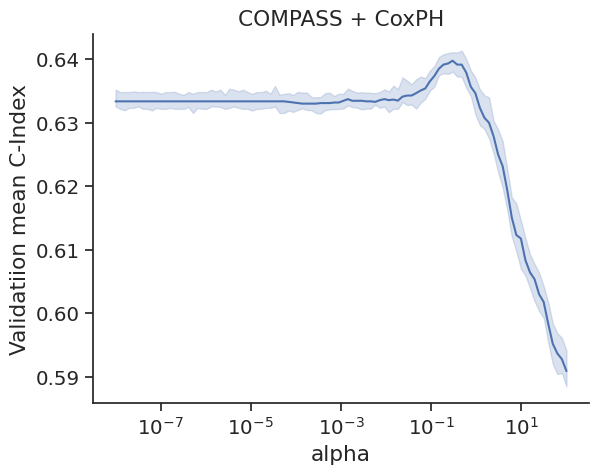

In [6]:
features = x.columns

repetitions = 5
scale = False
alphas = list(10. ** np.linspace(-8, 2, 100))

cohort = 'Gide'
train_data = y[y.cohort != cohort][['time', 'event']].join(x)
test_data = y[y.cohort == cohort][['time', 'event']].join(x)

if scale:

    X_scaler = StandardScaler()
    X_train = pd.DataFrame(X_scaler.fit_transform(train_data[features]), 
                           index =train_data.index, columns =features )
    X_test = pd.DataFrame(X_scaler.transform(test_data[features]), 
                           index =test_data.index, columns =features )

    data_train = X_train.join(y)
    data_test = X_test.join(y)

else:
    data_train = train_data
    data_test = test_data


res = []
for alpha in alphas:

    for fd in range(repetitions):
        inner_train_data, inner_valid_data = train_test_split(
            data_train, 
            test_size=0.1, 
            random_state=fd,
            stratify=train_data[['event']])

        Y = inner_train_data[['event', 'time']].to_records(index=False)
        X = inner_train_data[features]

        coxph = CoxPHSurvivalAnalysis(alpha=alpha)
        coxph.fit(X, Y)
        coxph_predict = coxph.predict(inner_valid_data[features])

        cind = concordance_index_censored(np.array(inner_valid_data['event']), 
                                          np.array(inner_valid_data['time']), 
                                          coxph_predict)

        res.append({'alpha':alpha,'fold':fd, 'cindex':cind[0]})

dfp = pd.DataFrame(res)

fig, ax = plt.subplots()
sns.lineplot(data=dfp, x = 'alpha', y = 'cindex', ax=ax, errorbar=('ci', 20),)
ax.set_xscale('log')

ax.tick_params(bottom=True, left=True)
ax.set_ylabel('Validatiion mean C-Index')
ax.set_title('COMPASS + CoxPH')
sns.despine(fig)


In [7]:
best_alpha = dfp.groupby('alpha').cindex.mean().idxmax()
best_alpha

0.298364724028334

### Build CoxPH based on best alpha

In [8]:
coxph = CoxPHSurvivalAnalysis(alpha=best_alpha) #maxCindex['alphas']
coxph.fit(data_train[features], data_train[['event', 'time']].to_records(index=False))
data_train['risk_score'] =  coxph.predict(data_train[features])
risk_scaler = MinMaxScaler()
data_train[['risk_score']] = risk_scaler.fit_transform(data_train[['risk_score']])
threshold = data_train['risk_score'].quantile(0.5)
data_train['Pred_Risk'] = data_train['risk_score'].apply(lambda x: 'High-risk' if x >= threshold else 'Low-risk')
data_train['best_alpha'] = best_alpha

train_cindex = concordance_index(data_train['time'], -data_train['risk_score'], data_train['event'])
print(f'Training C-index: {round(train_cindex,3)}')

Training C-index: 0.678


## Make prediction based on the model

Test C-index: 0.71


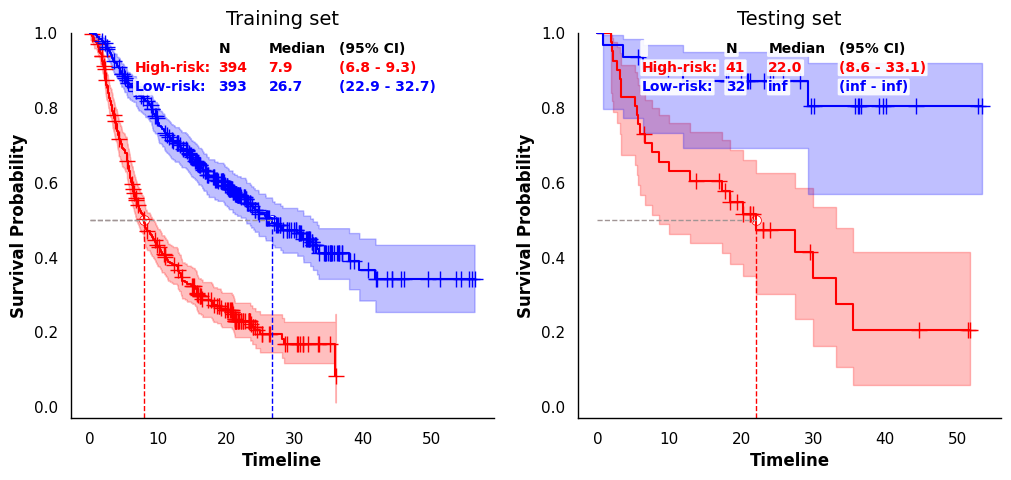

In [9]:
data_test['risk_score'] =  coxph.predict(data_test[features])
data_test[['risk_score']] = risk_scaler.fit_transform(data_test[['risk_score']])
data_test['Pred_Risk'] = data_test['risk_score'].apply(lambda x: 'High-risk' if x >= threshold else 'Low-risk')
data_test['best_alpha'] = best_alpha
test_cindex = concordance_index(data_test['time'], -data_test['risk_score'], data_test['event'])
print(f'Test C-index: {round(test_cindex,3)}')


## Visulization
fig, axs = plt.subplots(ncols=2, nrows=1, figsize = (12,5))
KMPlot(data_train, time='time', event='event', label=['Pred_Risk']).plot(ax=axs[0], 
                                                                        colors = ['red', 'blue'],
                                                                        title='Training set',
                                                                        ci_show=True)
KMPlot(data_test, time='time', event='event', label=['Pred_Risk']).plot(ax=axs[1],
                                                                        colors = ['red', 'blue'],
                                                                        ci_show=True,
                                                                        title='Testing set')

## Discussions

In this example, we illustrated how COMPASS conceptor features can be seamlessly integrated into a CoxPH model for survival prediction. By leveraging the pretrained concept representations, the model achieves biologically grounded and interpretable risk stratification. In practice, these features can also be extracted from a **fine-tuned COMPASS model**, which may further improve predictive performance by adapting to specific cancer types, cohorts, or therapeutic contexts. This flexibility highlights the value of COMPASS as a generalizable feature extractor that bridges modern deep learning representations with classical survival analysis, enabling both **accurate prediction** and **biological interpretability** in clinical applications.
